<a href="https://colab.research.google.com/github/Omorusi/Neural-network/blob/main/Apple_%26_Tomatoes_classifier_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [13]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import glob
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision import datasets  # Ensure this line is present


In [14]:
import os
import shutil
import random

# Original folders
apple_source = "/content/sample_data/Apples"
tomato_source = "/content/sample_data/Tomatoes"

# New dataset base folder
base_path = "/content/sample_data/dataset"

# Create folders
folders = [
    "train/apples",
    "train/tomatoes",
    "test/apples",
    "test/tomatoes"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

# Function to split images
def split_images(source_folder, train_folder, test_folder, split_ratio=0.8):

    images = os.listdir(source_folder)

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)

    train_images = images[:split_index]
    test_images = images[split_index:]

    for image in train_images:

        shutil.copy(
            os.path.join(source_folder, image),
            os.path.join(train_folder, image)
        )

    for image in test_images:

        shutil.copy(
            os.path.join(source_folder, image),
            os.path.join(test_folder, image)
        )

# Split apple images
split_images(
    apple_source,
    "/content/sample_data/dataset/train/apples",
    "/content/sample_data/dataset/test/apples"
)

# Split tomato images
split_images(
    tomato_source,
    "/content/sample_data/dataset/train/tomatoes",
    "/content/sample_data/dataset/test/tomatoes"
)

print("Dataset created successfully!")

Dataset created successfully!


In [15]:


# Download latest version
path = "/content/sample_data"
print("Dataset Path:", path)

Dataset Path: /content/sample_data


#Data Preparation

In [16]:
# -------------------------------
# DATASET PATHS
# -------------------------------

train_folder = os.path.join(path, 'train')
test_folder = os.path.join(path, 'test')

# Apple folders
train_folder_apples = os.path.join(train_folder, 'apples')
test_folder_apples = os.path.join(test_folder, 'apples')

# Tomato folders
train_folder_tomatoes = os.path.join(train_folder, 'tomatoes')
test_folder_tomatoes = os.path.join(test_folder, 'tomatoes')

# -------------------------------
# LOAD IMAGE FILES
# -------------------------------

train_image_files_apples = glob.glob(
    os.path.join(train_folder_apples, '*.*')
)

test_image_files_apples = glob.glob(
    os.path.join(test_folder_apples, '*.*')
)

train_image_files_tomatoes = glob.glob(
    os.path.join(train_folder_tomatoes, '*.*')
)

test_image_files_tomatoes = glob.glob(
    os.path.join(test_folder_tomatoes, '*.*')
)

print("Training apple images:", len(train_image_files_apples))
print("Testing apple images:", len(test_image_files_apples))

print("Training tomato images:", len(train_image_files_tomatoes))
print("Testing tomato images:", len(test_image_files_tomatoes))

Training apple images: 0
Testing apple images: 0
Training tomato images: 0
Testing tomato images: 0


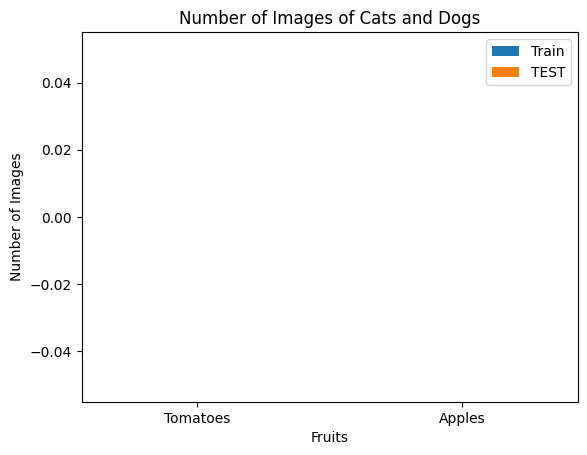

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the counts for tomatoes and apples in validation and train sets

tomatoes_test_count = len(test_image_files_tomatoes)
apples_test_count = len(test_image_files_apples)

tomatoes_train_count = len(train_image_files_tomatoes)
apples_train_count = len(train_image_files_apples)

# Create the labels for the x-axis
labels = ['Tomatoes', 'Apples']

# Create the counts for validation and train sets
validation_counts = [tomatoes_test_count, apples_test_count]
train_counts = [tomatoes_train_count, apples_train_count]

# Set the positions and width of the bars
positions = np.arange(len(labels))
bar_width = 0.35

# Plot the bars
plt.bar(positions - bar_width/2, train_counts, bar_width, label='Train')
plt.bar(positions + bar_width/2, validation_counts, bar_width, label='TEST')

# Set the labels and title
plt.xlabel('Fruits')
plt.ylabel('Number of Images')
plt.title('Number of Images of Cats and Dogs')

# Set the x-axis tick labels
plt.xticks(positions, labels)

# Add a legend
plt.legend()

# Show the plot
plt.show()

In [18]:
# -------------------------------
# STEP 2: Define Image Transformations
# -------------------------------
def convert_channels(image):
    image = np.array(image)
    if image.shape[2] == 4:  # RGBA -> RGB
        image = image[:, :, :3]
    elif image.shape[2] == 1:  # Grayscale -> RGB
        image = np.concatenate([image]*3, axis=2)
    return Image.fromarray(image)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Lambda(convert_channels),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5341, 0.5063, 0.4630],
                         std=[0.2098, 0.2081, 0.2181])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(convert_channels),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5341, 0.5063, 0.4630],
                         std=[0.2098, 0.2081, 0.2181])
])



In [20]:
import os

print(os.listdir('/content/sample_data'))

['anscombe.json', 'README.md', 'dataset', '.ipynb_checkpoints', 'Apples', 'Tomatoes', 'mnist_test.csv', 'mnist_train_small.csv', 'california_housing_train.csv', 'california_housing_test.csv']


In [21]:
print(os.listdir('/content/sample_data/dataset/train'))

['tomatoes', 'apples']


In [22]:
path = "/content/sample_data/dataset"

train_folder = os.path.join(path, 'train')
test_folder = os.path.join(path, 'test')

#Load Dataset

In [23]:
# -------------------------------
# LOAD DATASETS
# -------------------------------

# Training dataset
dataset = datasets.ImageFolder(
    root=train_folder,
    transform=train_transforms
)

# Split into train + validation
train_size = int(0.8 * len(dataset))
valid_size = len(dataset) - train_size

train_dataset, valid_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, valid_size]
)

# Validation transforms
valid_dataset.dataset.transform = val_transforms

# -------------------------------
# DATALOADERS
# -------------------------------

train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

# Test dataset
test_dataset = datasets.ImageFolder(
    root=test_folder,
    transform=val_transforms
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

Training images: 227
Validation images: 57
Test images: 108


#Define CNN Model

In [24]:
import torch
import torch.nn as nn

class BetterCNN(nn.Module):

    def __init__(self):
        super(BetterCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Linear(128 * 28 * 28, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 2)
        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = x.view(x.size(0), -1)

        x = self.fc_layers(x)

        return x

#Train and Evaluate Model

In [25]:


def train_model(model, train_loader, valid_loader, device, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Model Accuracy: {accuracy:.2f}%')
    return accuracy

#Initialize Model and Device and train model

In [26]:
if __name__ == "__main__":

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print("Using device:", device)

    # Initialize model
    model = BetterCNN().to(device)

    # Train model
    train_model(
        model,
        train_dataloader,
        valid_dataloader,
        device,
        epochs=5
    )

    # Evaluate model
    evaluate_model(
        model,
        test_dataloader,
        device
    )

Using device: cuda
Epoch 1, Loss: 13.8113
Epoch 2, Loss: 6.9077
Epoch 3, Loss: 4.0953
Epoch 4, Loss: 1.5395
Epoch 5, Loss: 0.7047
Model Accuracy: 78.70%


#Single Image Prediction

In [29]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

def ImagePrediction(filepath, model, device):

    # Open image
    img = Image.open(filepath).convert("RGB")

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Transform image
    transform = transforms.Compose([

        transforms.Resize((224, 224)),

        transforms.ToTensor()
    ])

    # Convert to tensor
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Prediction mode
    model.eval()

    with torch.no_grad():

        output = model(img_tensor)

        _, pred = torch.max(output, 1)

    # Labels
    labels = ['apples', 'tomatoes']

    print("Predicted Label:", labels[pred.item()])

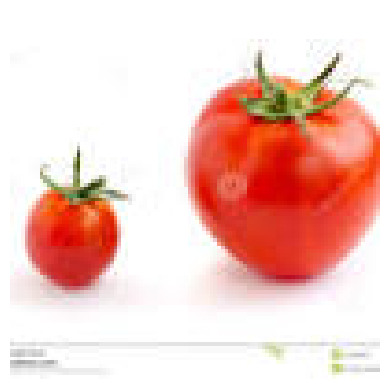

Predicted Label: apples


In [34]:
 ImagePrediction('/content/sample_data/Tomatoes/img_p1_10.jpeg', model, device)


In [ ]:
 ImagePrediction('/content/OIP (4).jpg', model, device)

In [ ]:
 ImagePrediction('/content/OIP (6).jpg', model, device)

In [ ]:
 ImagePrediction('/content/download (1).jpg', model, device)